<a href="https://colab.research.google.com/github/anupbagale/Whole-Brain-Segmentation/blob/main/Reduce_label_Brain_Segmentation_3D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***A. Data Preparation***

## ***1.Setup Environment***

In [ ]:
!python -c "import monai" || pip install -q "monai-weekly[gdown, nibabel, tqdm, ignite]"
!python -c "import matplotlib" || pip install -q matplotlib
%matplotlib inline

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'monai'
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 14.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 62.5 MB/s eta 0:00:00


## ***2.Import necessary libraries***

In [ ]:
from monai.utils import first, set_determinism
from monai.transforms import (
    AsDiscrete,
    AsDiscreted,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandCropByPosNegLabeld,
    SaveImaged,
    ScaleIntensityd,
    Spacingd,
    Invertd,
    ToTensord,
    Resized,
    Lambdad,
)
from monai.handlers.utils import from_engine
from monai.networks.nets import UNet
from monai.networks.layers import Norm
from monai.metrics import DiceMetric
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai.data import CacheDataset, DataLoader, Dataset, decollate_batch
from monai.config import print_config
from monai.apps import download_and_extract
import torch
import matplotlib.pyplot as plt
import tempfile
import shutil
import os
from glob import glob
import numpy as np
import nibabel as nib

print_config()

MONAI version: 1.4.dev2420
Numpy version: 1.25.2
Pytorch version: 2.3.0+cu121
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 4af7b3fbfa2fa119c6b7408d00bbe174ebda42bf
MONAI __file__: /usr/local/lib/python3.10/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 4.0.2
scikit-image version: 0.19.3
scipy version: 1.11.4
Pillow version: 9.4.0
Tensorboard version: 2.15.2
gdown version: 4.7.3
TorchVision version: 0.18.0+cu121
tqdm version: 4.66.4
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.0.3
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: 4.41.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.i

## ***3. Mount the drive***


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## ***4. Setup Temporary Root Directory***

In [ ]:
directory = os.environ.get("MONAI_DATA_DIRECTORY")
root_dir = tempfile.mkdtemp() if directory is None else directory
print(root_dir)

/tmp/tmp0pkzlo5t


## ***5. Extract Image Files and Label Files from the DataSet***


In [ ]:
image_directory='/content/drive/MyDrive/OASIS3_Dataset_Part4/Image_Folder'
label_directory='/content/drive/MyDrive/OASIS3_Dataset_Part4/Label_Folder'

In [ ]:
image_files=sorted(glob(f'{image_directory}/**/*.nii.gz*',recursive=True))
label_files=sorted(glob(f'{label_directory}/**/*.nii.gz*',recursive=True))
patient_data=[{'image':images,'label':labels} for images,labels in zip(image_files,label_files)]
train_data=patient_data[:60]
val_data=patient_data[60:]
print(f'Size of Train Files=',len(train_data),'\n Size of Validation Files=',len(val_data))

Size of Train Files= 60 
 Size of Validation Files= 24


## ***6. FreeSurfer Label Transformation and Colormap Visualization***

### **6.1 Creation of Custom Colormap Array in consistent with FreeSurfer using LookUp table with all standard 45 labels and reduced number of labels.**

In [ ]:
# Create a Custom Colormap Array in consistent with FreeSurfer
from matplotlib import colors
STD_LABEL_VALUES=np.array([0,2,3,4,5,7,8,10,11,12,13,14,15,16,17,18,24,26,28,30,31,41,42,43,44,46,47,49,50,51,52,53,54,58,60,62,63,77,80,85,251,252,253,254,255])
RED_LABEL_VALUES=np.array([0,2,3,4,7,8,10,11,12,13,14,15,16,17,28,31,41,42,43,46,47,49,50,51,52,53,60,63])
print(f'Standard Label Values \n',STD_LABEL_VALUES)
print(f'Reduced Label Values \n',RED_LABEL_VALUES)
print(f'Number of Standard Label Values=',len(STD_LABEL_VALUES),'\n Number of Reduced Label Values=',len(RED_LABEL_VALUES))
colormap_path = '/content/drive/MyDrive/FreeSurferColorLUT.txt'
data=np.loadtxt(colormap_path,dtype=str)
label_index=data[:,0].astype(np.int16)
label_cmap=data[:,2:5].astype(np.int16)/255
cmap_array=np.zeros((45,3))
for i,label in zip(range(len(STD_LABEL_VALUES)),STD_LABEL_VALUES):
  Loc=np.where(label_index==label)[0][0]
  cmap_array[i]=label_cmap[Loc]
red_cmap_array1=np.zeros((28,3))
for j,label in zip(range(len(RED_LABEL_VALUES)),RED_LABEL_VALUES):
  Loc1=np.where(label_index==label)[0][0]
  red_cmap_array1[j]=label_cmap[Loc1]




Standard Label Values 
 [  0   2   3   4   5   7   8  10  11  12  13  14  15  16  17  18  24  26
  28  30  31  41  42  43  44  46  47  49  50  51  52  53  54  58  60  62
  63  77  80  85 251 252 253 254 255]
Reduced Label Values 
 [ 0  2  3  4  7  8 10 11 12 13 14 15 16 17 28 31 41 42 43 46 47 49 50 51
 52 53 60 63]
Number of Standard Label Values= 45 
 Number of Reduced Label Values= 28


### **6.2 Creation of functions to transform standard label values to normal vectorized indices and reduced label indices.**

In [ ]:
# Create a Function to Change the Full freesurface label indices to normal indices
def Replace_FS_Index(Label_data):
  for items in STD_LABEL_VALUES:
    Label_data[Label_data==items]=np.where(STD_LABEL_VALUES==items)[0][0]
  return Label_data

#Create a Function to change the reduced freesurfer indices to normal indices
def Replace_Red_FS_Index(Label_data):
  dis_ele=np.setdiff1d(STD_LABEL_VALUES,RED_LABEL_VALUES)
  for items in dis_ele:
    Label_data[Label_data==items]=0
  for elements in RED_LABEL_VALUES:
    Label_data[Label_data==elements]=np.where(RED_LABEL_VALUES==elements)[0][0]
  return Label_data

### **6.3 Visualize a sample image along with its standard labels and reduced labels.**

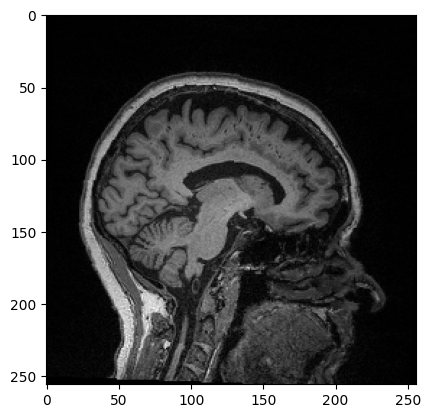

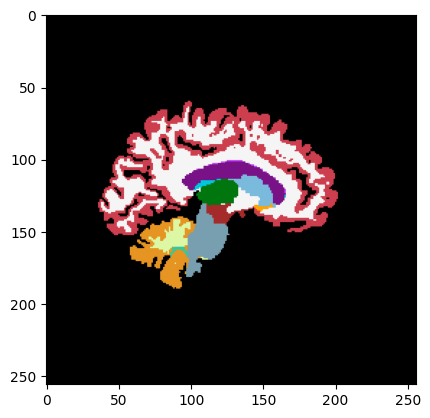

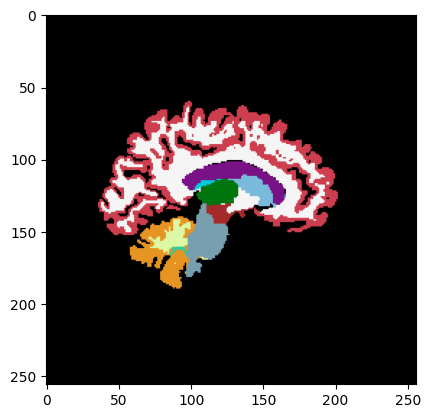

In [ ]:
img_data=nib.load(image_files[0]).get_fdata()
label_data=nib.load(label_files[0]).get_fdata()
mod_label_data=Replace_FS_Index(label_data)
colored_label_data=cmap_array[mod_label_data.astype(np.int16)]
plt.imshow(img_data[118,:,:],cmap='gray')
plt.show()
plt.imshow(colored_label_data[118,:,:])
plt.show()
label_data=nib.load(label_files[0]).get_fdata()
mod_label_data1=Replace_Red_FS_Index(label_data)
col_mod_label_data1=red_cmap_array1[mod_label_data1.astype(np.int16)]
plt.imshow(col_mod_label_data1[118,:,:])
plt.show()






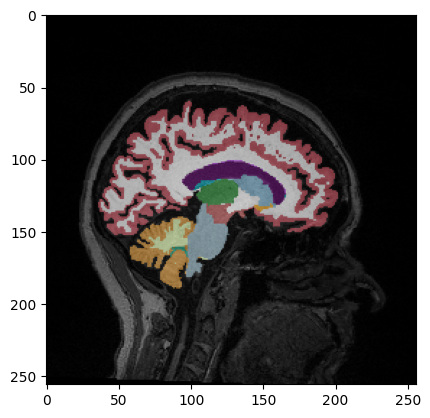

In [ ]:
img_data=nib.load(image_files[0]).get_fdata()
label_data=nib.load(label_files[0]).get_fdata()
mod_label_data=Replace_FS_Index(label_data)
colored_label_data=cmap_array[mod_label_data.astype(np.int16)]
plt.imshow(img_data[118,:,:],cmap='gray')
plt.imshow(colored_label_data[118,:,:],alpha=0.5)
plt.show()

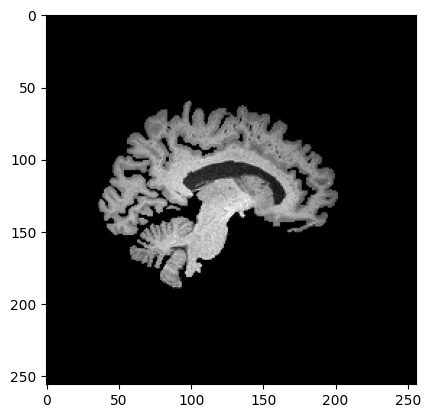

In [ ]:
img_data=nib.load(image_files[0]).get_fdata()
label_data=nib.load(label_files[0]).get_fdata()
img_data[label_data==0]=0
mod_label_data=Replace_FS_Index(label_data)
colored_label_data=cmap_array[mod_label_data.astype(np.int16)]
plt.imshow(img_data[118,:,:],cmap='gray')
plt.imshow(colored_label_data[118,:,:],alpha=0.0)
plt.show()

In [ ]:
ext_img_data=np.expand_dims(img_data,axis=0)
ext_label_data=np.expand_dims(label_data,axis=0)


(1, 256, 256, 256) (1, 256, 256, 256)


In [ ]:
from monai.transforms import CropForeground

In [ ]:
Cropper=CropForeground()
cropped_img_data=Cropper(ext_img_data)
cropped_label_data=Cropper(ext_label_data)
print(cropped_img_data.shape,cropped_label_data.shape)
print(np.max(label_data))

/usr/local/lib/python3.10/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.array CropForeground.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


torch.Size([1, 132, 140, 166]) torch.Size([1, 132, 140, 166])
44.0


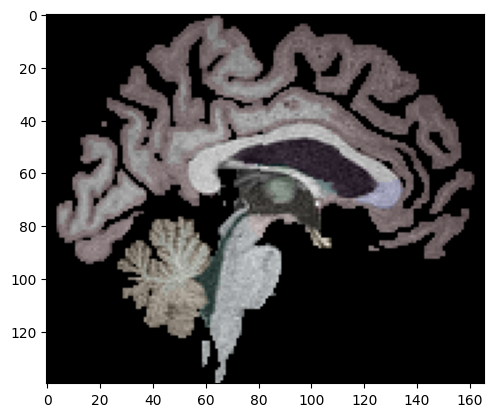

In [ ]:
plt.imshow(cropped_img_data[0,65,:,:],cmap='gray')
plt.imshow(cmap_array[cropped_label_data.astype(np.int16)[0,65,:,:]],alpha=0.1)
plt.show()

# ***B. Preparation For Model Training and Validation***

## ***1. Set deterministic training for reproducibility***

In [ ]:
set_determinism(seed=0)

## ***2. Setup transforms for training and validation for full standard labels and reduced labels.***



In [ ]:
std_train_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        Lambdad(keys="label",func=Replace_FS_Index),
        ToTensord(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Resized(keys=["image","label"],spatial_size=(128,128,128),mode=['area','nearest']),
        ScaleIntensityd(keys="image", minv=0, maxv=1),
    ]
)
std_val_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        Lambdad(keys="label",func=Replace_FS_Index),
        ToTensord(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Resized(keys=["image","label"],spatial_size=(128,128,128),mode=['area','nearest']),
        ScaleIntensityd(keys="image", minv=0, maxv=1),
    ]
)
red_train_transforms=Compose(
    [
        LoadImaged(keys=["image", "label"]),
        Lambdad(keys="label",func=Replace_Red_FS_Index),
        ToTensord(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Resized(keys=["image","label"],spatial_size=(128,128,128),mode=['area','nearest']),
        ScaleIntensityd(keys="image", minv=0, maxv=1),
    ]
)
red_val_transforms=Compose(
    [
        LoadImaged(keys=["image", "label"]),
        Lambdad(keys="label",func=Replace_Red_FS_Index),
        ToTensord(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Resized(keys=["image","label"],spatial_size=(128,128,128),mode=['area','nearest']),
        ScaleIntensityd(keys="image", minv=0, maxv=1),
    ]
)

## ***3. Check transforms in DataLoader***

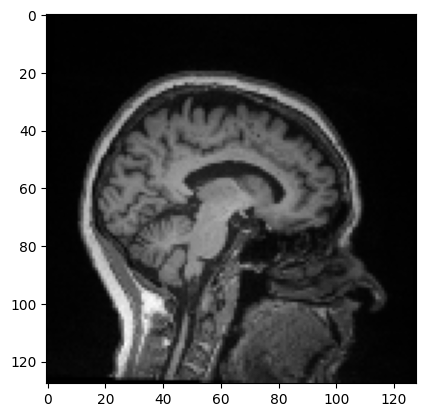

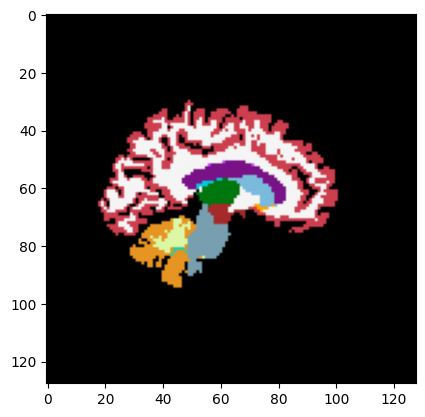

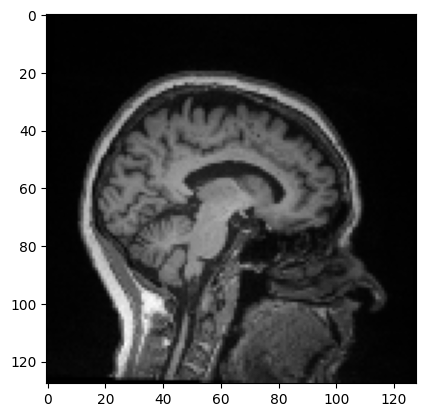

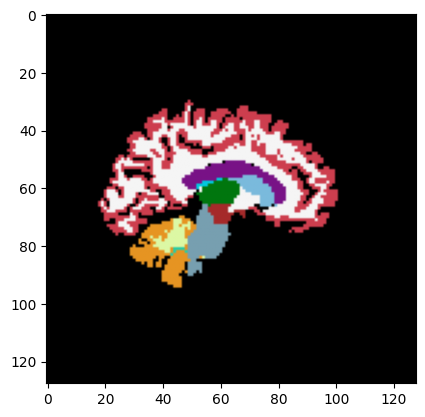

In [ ]:
#Check transformation for full standard labels
std_check_ds = Dataset(data=train_data, transform=std_train_transforms)
std_check_loader = DataLoader(std_check_ds, batch_size=1)
img_data=std_check_ds[0]['image']
label_data=std_check_ds[0]['label']
colored_label_data=cmap_array[label_data.astype(np.int16)]
plt.imshow(img_data[0,59,:,:],cmap='gray')
plt.show()
plt.imshow(colored_label_data[0,59,:,:])
plt.show()

#Check transformation for reduced labels
red_check_ds = Dataset(data=train_data, transform=red_train_transforms)
red_check_loader = DataLoader(red_check_ds, batch_size=1)
red_img_data=red_check_ds[0]['image']
red_label_data=red_check_ds[0]['label']
red_colored_label_data=red_cmap_array1[red_label_data.astype(np.int16)]
plt.imshow(red_img_data[0,59,:,:],cmap='gray')
plt.show()
plt.imshow(red_colored_label_data[0,59,:,:])
plt.show()


# ***C. Definition of Full Standard Dataset/DataLoader and Reduced Dataset/DataLoader. Creation of UNet Model that trains on Full Standard Label Values and Reduced Label Values.***

## ***1. Define Dataset and DataLoader for training and validation for full standard labels and reduced labels.***



In [ ]:
#Define dataset and dataloader for training and validating on the same set of data using full standard labels and reduced number of labels
# Define dataset and dataloader for full standard labels
Full_simple_train_ds = Dataset(data=train_data[10:20], transform=std_train_transforms)
Full_simple_train_loader = DataLoader(Full_simple_train_ds, batch_size=1, shuffle=True, num_workers=0)
Full_simple_val_ds = Dataset(data=train_data[10:20], transform=std_val_transforms)
Full_simple_val_loader = DataLoader(Full_simple_val_ds, batch_size=1, num_workers=0)

# Define dataset and dataloader for reduced number of labels
Red_simple_train_ds = Dataset(data=train_data[10:20], transform=red_train_transforms)
Red_simple_train_loader = DataLoader(Red_simple_train_ds, batch_size=1, shuffle=True, num_workers=0)
Red_simple_val_ds = Dataset(data=train_data[10:20], transform=red_val_transforms)
Red_simple_val_loader = DataLoader(Red_simple_val_ds, batch_size=1, num_workers=0)

#Define dataset and dataloader for training and validating on different set of data using full standard labels and reduced number of labels
# Define dataset and dataloader for full standard labels
Full_complete_train_ds = Dataset(data=train_data, transform=std_train_transforms)
Full_complete_train_loader = DataLoader(Full_complete_train_ds, batch_size=1, shuffle=True, num_workers=0)
Full_complete_val_ds = Dataset(data=val_data, transform=std_val_transforms)
Full_complete_val_loader = DataLoader(Full_complete_val_ds, batch_size=1, num_workers=0)

# Define dataset and dataloader for reduced number of labels
Red_complete_train_ds = Dataset(data=train_data, transform=red_train_transforms)
Red_complete_train_loader = DataLoader(Red_complete_train_ds, batch_size=1, shuffle=True, num_workers=0)
Red_complete_val_ds = Dataset(data=val_data, transform=red_val_transforms)
Red_complete_val_loader = DataLoader(Red_complete_val_ds, batch_size=1, num_workers=0)

## ***2. Create Model, Loss, Optimizer for standard training and reduced training***

In [ ]:
# standard PyTorch program style: create UNet, DiceLoss and Adam optimizer
device = torch.device("cuda:0")
std_model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=45,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.BATCH,
).to(device)
red_model= UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=28,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.BATCH,
).to(device)
loss_function = DiceLoss(to_onehot_y=True, softmax=True)
std_optimizer = torch.optim.Adam(std_model.parameters(), 1e-3)
red_optimizer= torch.optim.Adam(red_model.parameters(), 1e-3)
dice_metric = DiceMetric(include_background=False, reduction="mean")

# ***D. Execution of Typical Pytorch Training Process***

## ***1. Training and Validation on the same set of data using full standard labels***

### **1.1 Execute a Typical Pytorch Training Process**

In [ ]:
max_epochs = 350
val_interval = 2
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []
post_pred = Compose([AsDiscrete(argmax=True, to_onehot=45)])
post_label = Compose([AsDiscrete(to_onehot=45)])

for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step += 1
        inputs, labels = (
            batch_data["image"].to(device),
            batch_data["label"].to(device),
        )
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        print(f"{step}/{len(train_ds) // train_loader.batch_size}, " f"train_loss: {loss.item():.4f}")
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = (
                    val_data["image"].to(device),
                    val_data["label"].to(device),
                )
                roi_size = (128,128,128)
                sw_batch_size = 4
                val_outputs = sliding_window_inference(val_inputs, roi_size, sw_batch_size, model)
                val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]
                val_labels = [post_label(i) for i in decollate_batch(val_labels)]
                # compute metric for current iteration
                dice_metric(y_pred=val_outputs, y=val_labels)

            # aggregate the final mean dice result
            metric = dice_metric.aggregate().item()
            # reset the status for next validation round
            dice_metric.reset()

            metric_values.append(metric)
            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), os.path.join(root_dir, "best_metric_model.pth"))
                print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current mean dice: {metric:.4f}"
                f"\nbest mean dice: {best_metric:.4f} "
                f"at epoch: {best_metric_epoch}"
            )

----------
epoch 1/350
1/10, train_loss: 0.9895
2/10, train_loss: 0.9874
3/10, train_loss: 0.9850
4/10, train_loss: 0.9767
5/10, train_loss: 0.9815
6/10, train_loss: 0.9706
7/10, train_loss: 0.9735
8/10, train_loss: 0.9653
9/10, train_loss: 0.9630
10/10, train_loss: 0.9581
epoch 1 average loss: 0.9751
----------
epoch 2/350
1/10, train_loss: 0.9559
2/10, train_loss: 0.9500
3/10, train_loss: 0.9481
4/10, train_loss: 0.9431
5/10, train_loss: 0.9480
6/10, train_loss: 0.9498
7/10, train_loss: 0.9492
8/10, train_loss: 0.9426
9/10, train_loss: 0.9343
10/10, train_loss: 0.9419
epoch 2 average loss: 0.9463
saved new best metric model
current epoch: 2 current mean dice: 0.0151
best mean dice: 0.0151 at epoch: 2
----------
epoch 3/350
1/10, train_loss: 0.9430
2/10, train_loss: 0.9271
3/10, train_loss: 0.9265
4/10, train_loss: 0.9251
5/10, train_loss: 0.9190
6/10, train_loss: 0.9130
7/10, train_loss: 0.9197
8/10, train_loss: 0.9176
9/10, train_loss: 0.9108
10/10, train_loss: 0.9048
epoch 3 averag

KeyboardInterrupt: 

In [ ]:
print(f"train completed, best_metric: {best_metric:.4f} " f"at epoch: {best_metric_epoch}")

train completed, best_metric: 0.7274 at epoch: 284


### **1.2 Plot the loss and metric**

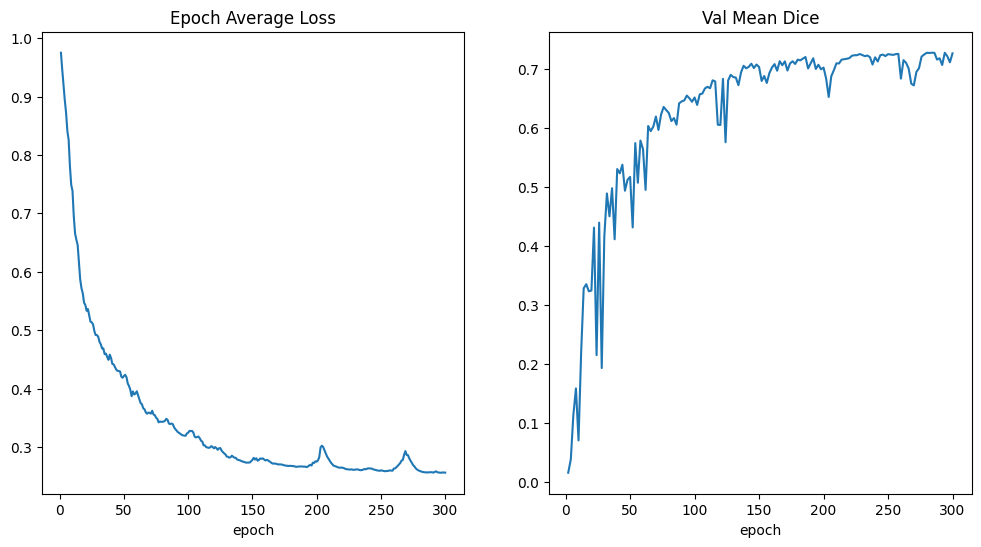

In [ ]:
plt.figure("train", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.subplot(1, 2, 2)
plt.title("Val Mean Dice")
x = [val_interval * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.show()

### **1.3 Check best model output with the input image and label**

torch.Size([1, 1, 128, 128, 128])


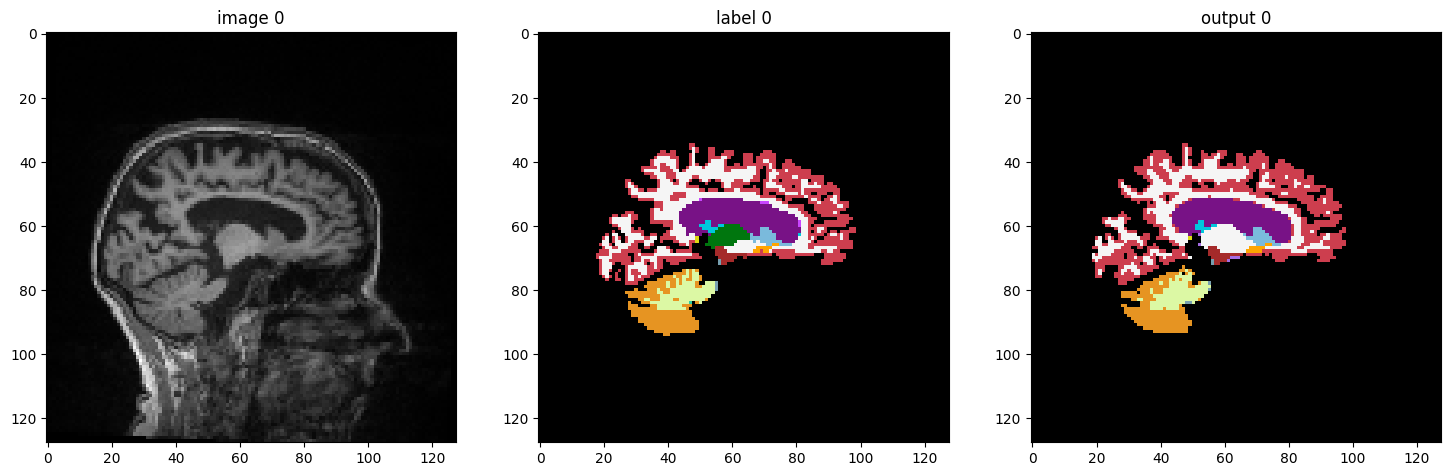

torch.Size([1, 1, 128, 128, 128])


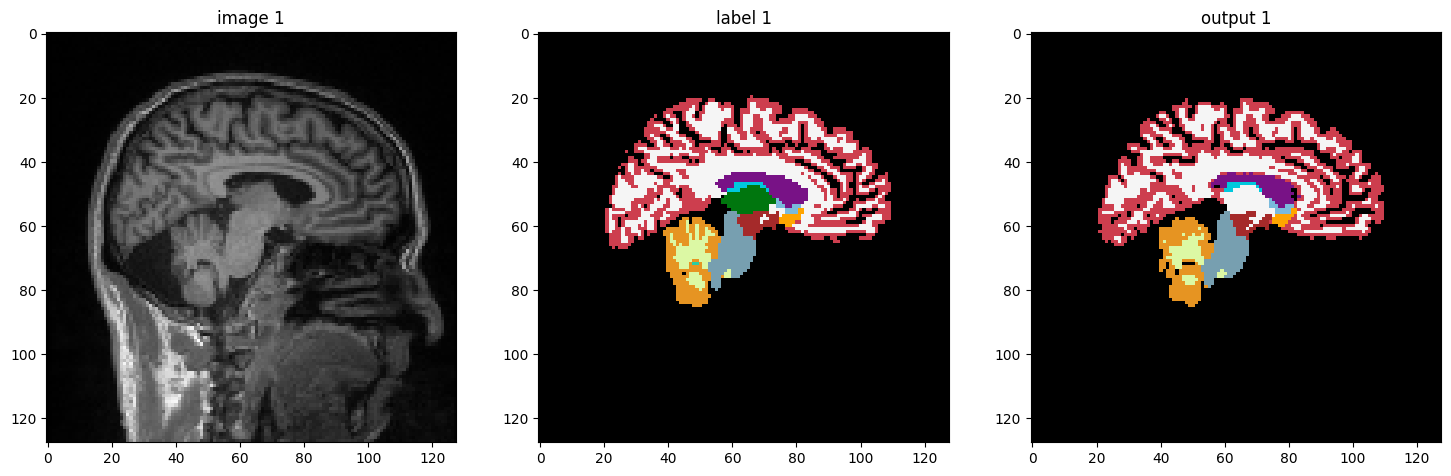

In [ ]:
model.load_state_dict(torch.load(os.path.join(root_dir, "best_metric_model.pth")))
model.eval()
with torch.no_grad():
    for i, val_data in enumerate(val_loader):
      print(val_data['image'].shape)
      roi_size = (128, 128, 128)
      sw_batch_size = 4
      val_outputs = sliding_window_inference(val_data["image"].to(device), roi_size, sw_batch_size, model)
        # plot the slice [:, :, 80]
      plt.figure("check", (18, 6))
      plt.subplot(1, 3, 1)
      plt.title(f"image {i}")
      plt.imshow(val_data["image"][0, 0, 59, :, :], cmap="gray")
      plt.subplot(1, 3, 2)
      plt.title(f"label {i}")
      col_val_data=cmap_array[val_data["label"][0,0,:,:,:].astype(np.int16)]
      plt.imshow(col_val_data[59,:,:])
      plt.subplot(1, 3, 3)
      plt.title(f"output {i}")
      col_val_out=cmap_array[torch.argmax(val_outputs, dim=1).detach().cpu().astype(np.int16)]
      plt.imshow(col_val_out[0,59,:,:])
      plt.show()
      if i == 2:
          break

## ***2. Training and Validation of the model on different subsets of data using full standard labels.***

## ***Define DataSet and DataLoader***

In [ ]:
#train_ds = CacheDataset(data=train_files, transform=train_transforms, cache_rate=1.0, num_workers=4)
train_ds = Dataset(data=train_data, transform=train_transforms)

# use batch_size=2 to load images and use RandCropByPosNegLabeld
# to generate 2 x 4 images for network training
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=0)

#val_ds = CacheDataset(data=val_files, transform=val_transforms, cache_rate=1.0, num_workers=4)
val_ds = Dataset(data=val_data, transform=val_transforms)
val_loader = DataLoader(val_ds, batch_size=2, num_workers=0)

## ***Create Model, Loss and Optimizer***

In [ ]:
# standard PyTorch program style: create UNet, DiceLoss and Adam optimizer
device = torch.device("cuda:0")
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=45,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.BATCH,
).to(device)
loss_function = DiceLoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-3)
dice_metric = DiceMetric(include_background=False, reduction="mean")

## ***Execute a typical PyTorch Training Process***

In [ ]:
max_epochs = 350
val_interval = 2
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []
post_pred = Compose([AsDiscrete(argmax=True, to_onehot=45)])
post_label = Compose([AsDiscrete(to_onehot=45)])

for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step += 1
        inputs, labels = (
            batch_data["image"].to(device),
            batch_data["label"].to(device),
        )
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        print(f"{step}/{len(train_ds) // train_loader.batch_size}, " f"train_loss: {loss.item():.4f}")
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = (
                    val_data["image"].to(device),
                    val_data["label"].to(device),
                )
                roi_size = (128,128,128)
                sw_batch_size = 4
                val_outputs = sliding_window_inference(val_inputs, roi_size, sw_batch_size, model)
                val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]
                val_labels = [post_label(i) for i in decollate_batch(val_labels)]
                # compute metric for current iteration
                dice_metric(y_pred=val_outputs, y=val_labels)

            # aggregate the final mean dice result
            metric = dice_metric.aggregate().item()
            # reset the status for next validation round
            dice_metric.reset()

            metric_values.append(metric)
            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), os.path.join(root_dir, "best_metric_model_02.pth"))
                print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current mean dice: {metric:.4f}"
                f"\nbest mean dice: {best_metric:.4f} "
                f"at epoch: {best_metric_epoch}"
            )

----------
epoch 1/350
1/30, train_loss: 0.9966
2/30, train_loss: 0.9931
3/30, train_loss: 0.9908
4/30, train_loss: 0.9894
5/30, train_loss: 0.9856
6/30, train_loss: 0.9808
7/30, train_loss: 0.9783
8/30, train_loss: 0.9729
9/30, train_loss: 0.9722
10/30, train_loss: 0.9651
11/30, train_loss: 0.9646
12/30, train_loss: 0.9622
13/30, train_loss: 0.9550
14/30, train_loss: 0.9553
15/30, train_loss: 0.9524
16/30, train_loss: 0.9517
17/30, train_loss: 0.9492
18/30, train_loss: 0.9494
19/30, train_loss: 0.9438
20/30, train_loss: 0.9392
21/30, train_loss: 0.9423
22/30, train_loss: 0.9366
23/30, train_loss: 0.9338
24/30, train_loss: 0.9358
25/30, train_loss: 0.9307
26/30, train_loss: 0.9228
27/30, train_loss: 0.9236
28/30, train_loss: 0.9365
29/30, train_loss: 0.9181
30/30, train_loss: 0.9175
epoch 1 average loss: 0.9548
----------
epoch 2/350
1/30, train_loss: 0.9180
2/30, train_loss: 0.9058
3/30, train_loss: 0.9118
4/30, train_loss: 0.9035
5/30, train_loss: 0.9060
6/30, train_loss: 0.9121
7/30

KeyboardInterrupt: 

## ***Plot the loss and dice metric***

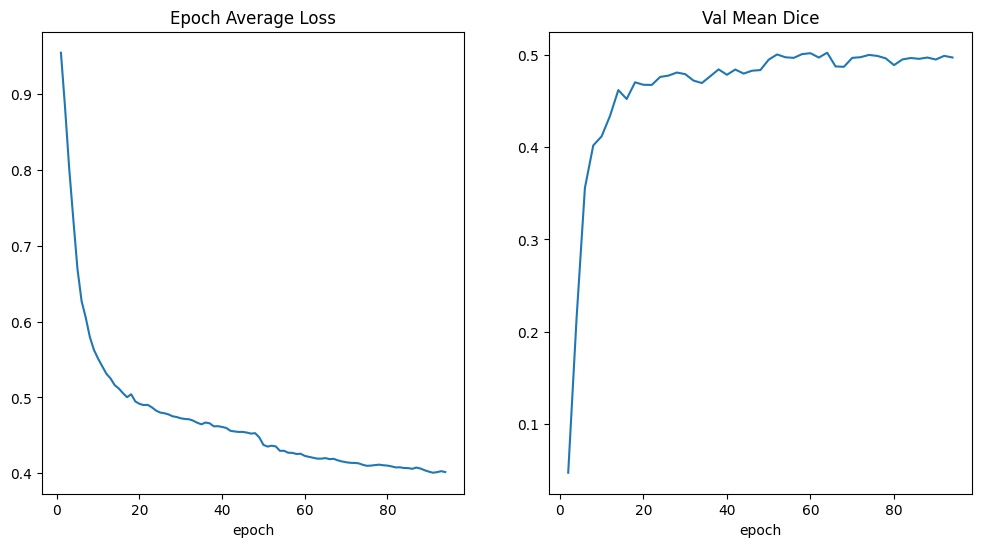

In [ ]:
plt.figure("train", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.subplot(1, 2, 2)
plt.title("Val Mean Dice")
x = [val_interval * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.show()

## ***Check the best model output with input image and label.***

torch.Size([2, 1, 128, 128, 128])


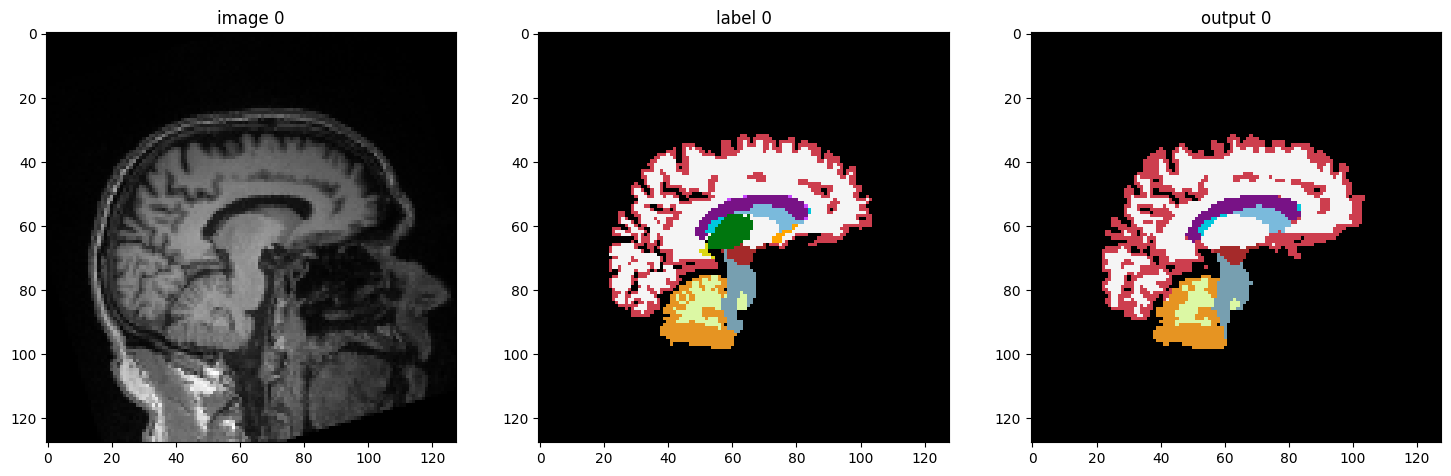

torch.Size([2, 1, 128, 128, 128])


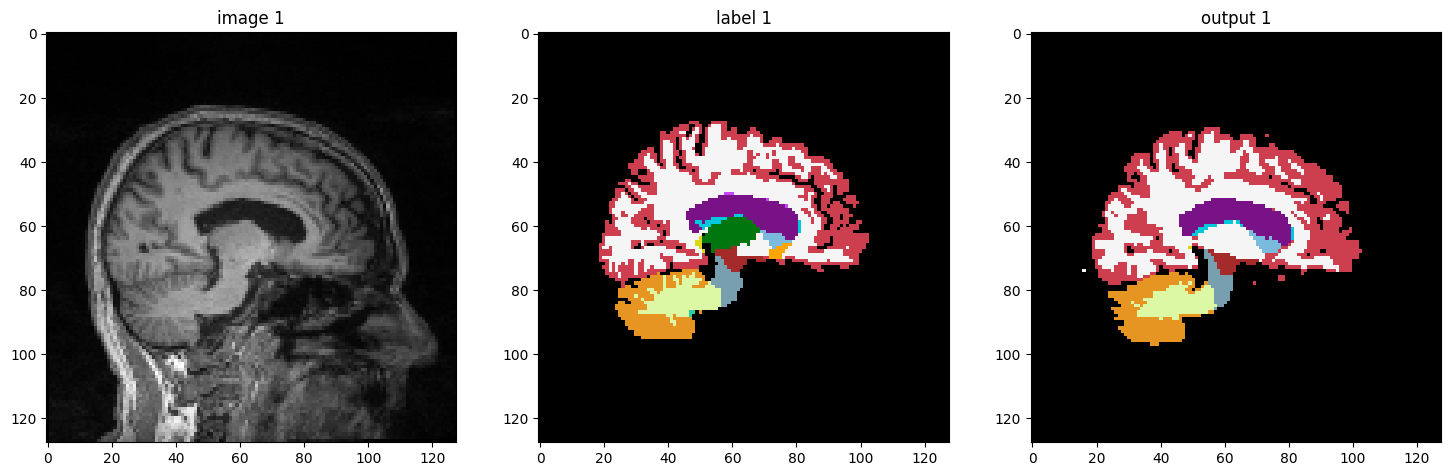

torch.Size([2, 1, 128, 128, 128])


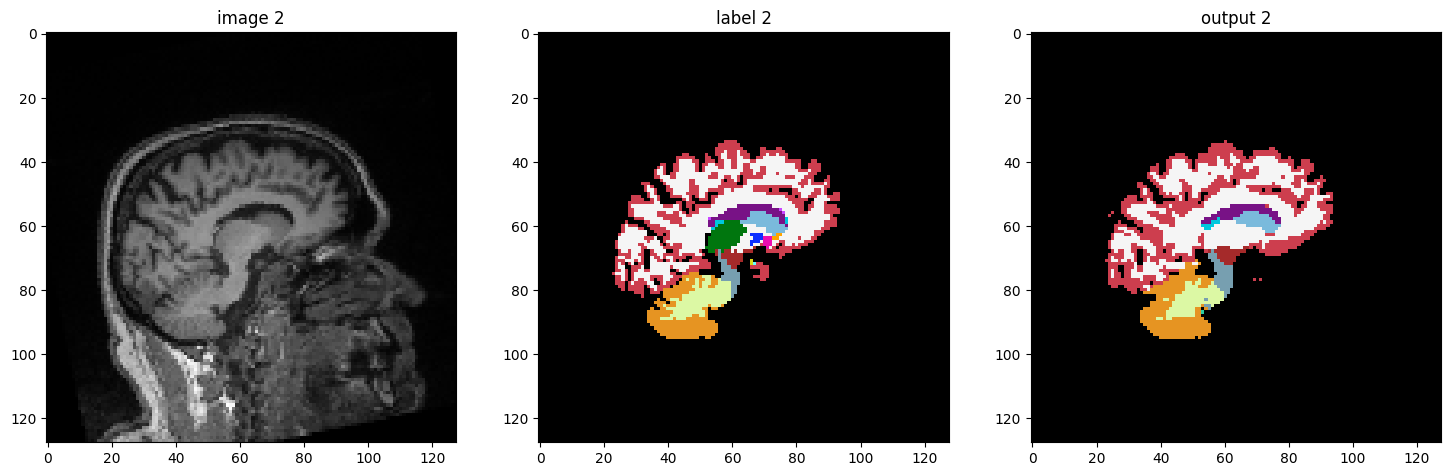

In [ ]:
model.load_state_dict(torch.load(os.path.join(root_dir, "best_metric_model_02.pth")))
model.eval()
with torch.no_grad():
    for i, val_data in enumerate(val_loader):
      print(val_data['image'].shape)
      roi_size = (128, 128, 128)
      sw_batch_size = 4
      val_outputs = sliding_window_inference(val_data["image"].to(device), roi_size, sw_batch_size, model)
        # plot the slice [:, :, 80]
      plt.figure("check", (18, 6))
      plt.subplot(1, 3, 1)
      plt.title(f"image {i}")
      plt.imshow(val_data["image"][0, 0, 59, :, :], cmap="gray")
      plt.subplot(1, 3, 2)
      plt.title(f"label {i}")
      col_val_data=cmap_array[val_data["label"][0,0,:,:,:].astype(np.int16)]
      plt.imshow(col_val_data[59,:,:])
      plt.subplot(1, 3, 3)
      plt.title(f"output {i}")
      col_val_out=cmap_array[torch.argmax(val_outputs, dim=1).detach().cpu().astype(np.int16)]
      plt.imshow(col_val_out[0,59,:,:])
      plt.show()
      if i == 2:
          break

## ***3. Training and Evaluating a model on the same subset of data and check for overfitting using reduced number of labels.***

In [ ]:
max_epochs = 300
val_interval = 2
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []
post_pred = Compose([AsDiscrete(argmax=True, to_onehot=28)])
post_label = Compose([AsDiscrete(to_onehot=28)])

for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    red_model.train()
    epoch_loss = 0
    step = 0
    for batch_data in Red_simple_train_loader:
        step += 1
        inputs, labels = (
            batch_data["image"].to(device),
            batch_data["label"].to(device),
        )
        red_optimizer.zero_grad()
        outputs = red_model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        red_optimizer.step()
        epoch_loss += loss.item()
        print(f"{step}/{len(Red_simple_train_ds) // Red_simple_train_loader.batch_size}, " f"train_loss: {loss.item():.4f}")
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        red_model.eval()
        with torch.no_grad():
            for val_data in Red_simple_val_loader:
                val_inputs, val_labels = (
                    val_data["image"].to(device),
                    val_data["label"].to(device),
                )
                roi_size = (128,128,128)
                sw_batch_size = 4
                val_outputs = sliding_window_inference(val_inputs, roi_size, sw_batch_size, red_model)
                val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]
                val_labels = [post_label(i) for i in decollate_batch(val_labels)]
                # compute metric for current iteration
                dice_metric(y_pred=val_outputs, y=val_labels)

            # aggregate the final mean dice result
            metric = dice_metric.aggregate().item()
            # reset the status for next validation round
            dice_metric.reset()

            metric_values.append(metric)
            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                torch.save(red_model.state_dict(), os.path.join(root_dir, "best_metric_red_model_simple.pth"))
                print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current mean dice: {metric:.4f}"
                f"\nbest mean dice: {best_metric:.4f} "
                f"at epoch: {best_metric_epoch}"
            )

----------
epoch 1/300
1/10, train_loss: 0.1921
2/10, train_loss: 0.1977
3/10, train_loss: 0.1869
4/10, train_loss: 0.1857
5/10, train_loss: 0.2034
6/10, train_loss: 0.1890
7/10, train_loss: 0.2034
8/10, train_loss: 0.1910
9/10, train_loss: 0.2036
10/10, train_loss: 0.2013
epoch 1 average loss: 0.1954
----------
epoch 2/300
1/10, train_loss: 0.1964
2/10, train_loss: 0.1941
3/10, train_loss: 0.1953
4/10, train_loss: 0.1882
5/10, train_loss: 0.1962
6/10, train_loss: 0.2000
7/10, train_loss: 0.2002
8/10, train_loss: 0.2016
9/10, train_loss: 0.2046
10/10, train_loss: 0.1888
epoch 2 average loss: 0.1965
saved new best metric model
current epoch: 2 current mean dice: 0.7301
best mean dice: 0.7301 at epoch: 2
----------
epoch 3/300
1/10, train_loss: 0.1948
2/10, train_loss: 0.2048
3/10, train_loss: 0.2233
4/10, train_loss: 0.1874
5/10, train_loss: 0.1898
6/10, train_loss: 0.2011
7/10, train_loss: 0.2074
8/10, train_loss: 0.2014
9/10, train_loss: 0.2044
10/10, train_loss: 0.1989
epoch 3 averag

torch.Size([1, 1, 128, 128, 128])


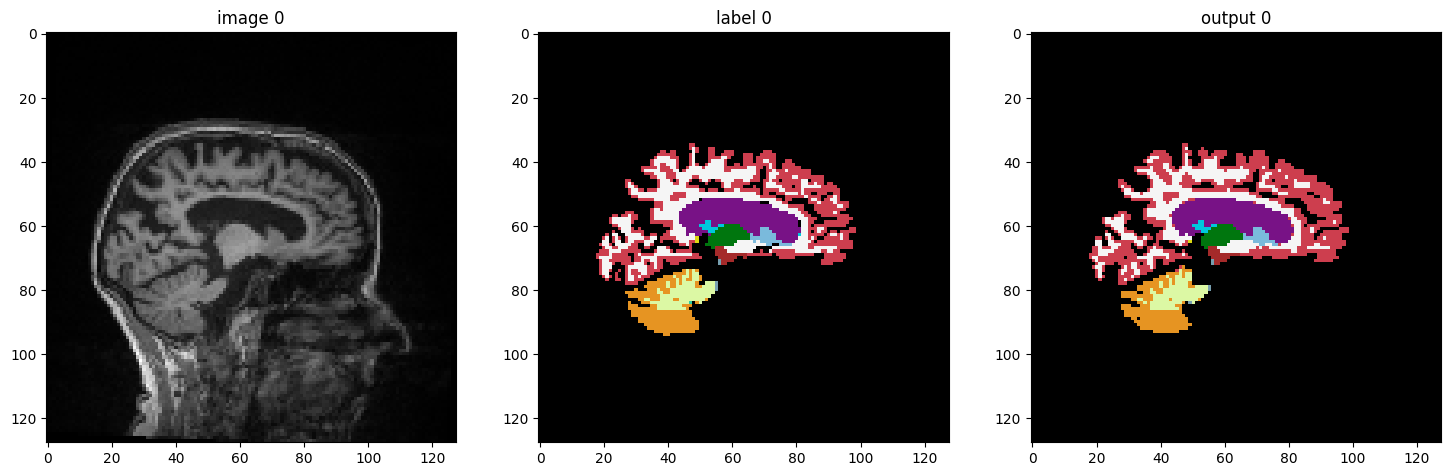

torch.Size([1, 1, 128, 128, 128])


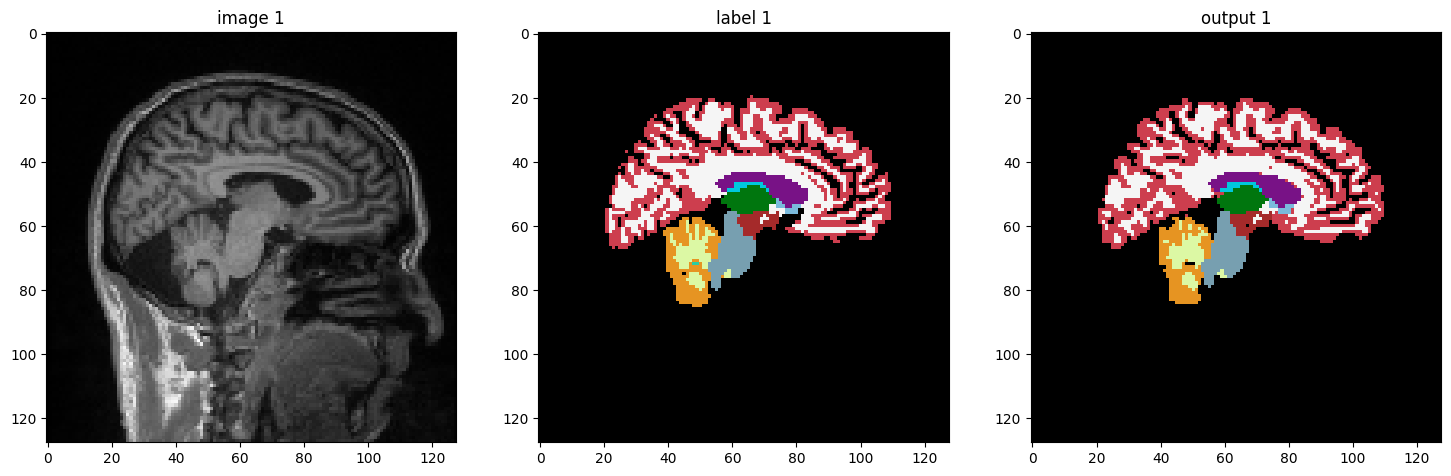

torch.Size([1, 1, 128, 128, 128])


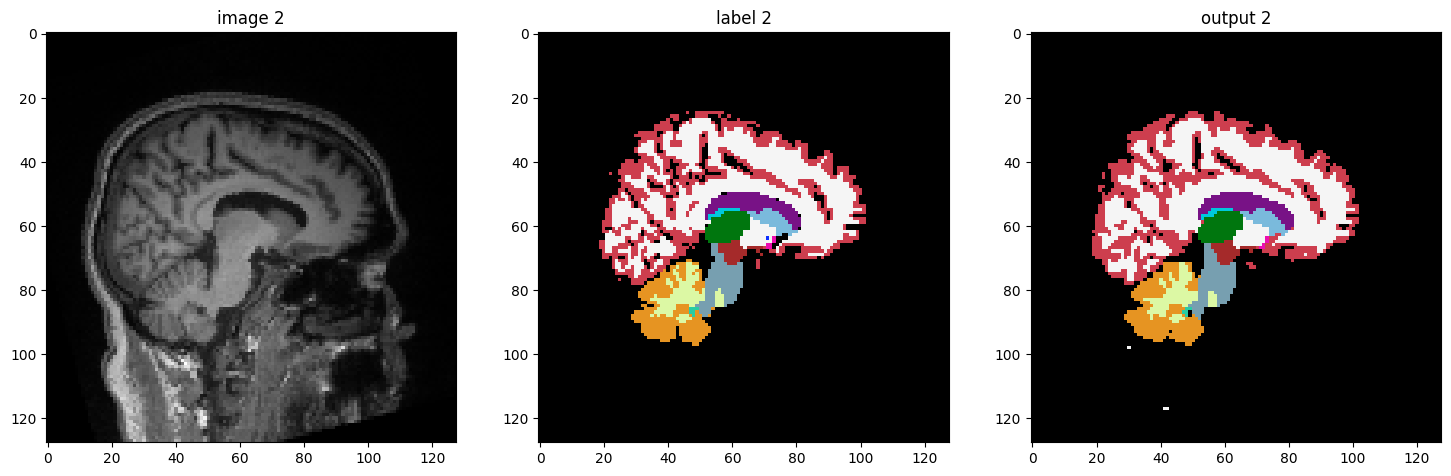

In [ ]:
red_model.load_state_dict(torch.load(os.path.join(root_dir, "best_metric_red_model_simple.pth")))
red_model.eval()
with torch.no_grad():
    for i, val_data in enumerate(Red_simple_val_loader):
      print(val_data['image'].shape)
      roi_size = (128, 128, 128)
      sw_batch_size = 4
      val_outputs = sliding_window_inference(val_data["image"].to(device), roi_size, sw_batch_size, red_model)
        # plot the slice [:, :, 80]
      plt.figure("check", (18, 6))
      plt.subplot(1, 3, 1)
      plt.title(f"image {i}")
      plt.imshow(val_data["image"][0, 0, 59, :, :], cmap="gray")
      plt.subplot(1, 3, 2)
      plt.title(f"label {i}")
      col_val_data=red_cmap_array1[val_data["label"][0,0,:,:,:].astype(np.int16)]
      plt.imshow(col_val_data[59,:,:])
      plt.subplot(1, 3, 3)
      plt.title(f"output {i}")
      col_val_out=red_cmap_array1[torch.argmax(val_outputs, dim=1).detach().cpu().astype(np.int16)]
      plt.imshow(col_val_out[0,59,:,:])
      plt.show()
      if i == 2:
          break

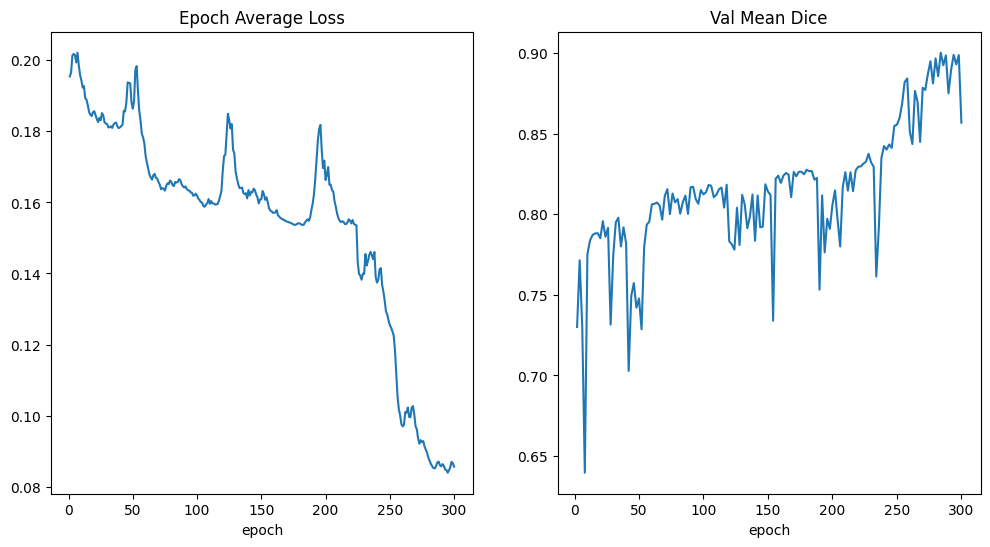

In [ ]:
plt.figure("train", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.subplot(1, 2, 2)
plt.title("Val Mean Dice")
x = [val_interval * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.show()

## Evaluation on original image spacings

In [ ]:
val_org_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Orientationd(keys=["image"], axcodes="RAS"),
        Spacingd(keys=["image"], pixdim=(1.5, 1.5, 2.0), mode="bilinear"),
        ScaleIntensityRanged(
            keys=["image"],
            a_min=-57,
            a_max=164,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
        CropForegroundd(keys=["image"], source_key="image"),
    ]
)

val_org_ds = Dataset(data=val_files, transform=val_org_transforms)
val_org_loader = DataLoader(val_org_ds, batch_size=1, num_workers=4)

post_transforms = Compose(
    [
        Invertd(
            keys="pred",
            transform=val_org_transforms,
            orig_keys="image",
            meta_keys="pred_meta_dict",
            orig_meta_keys="image_meta_dict",
            meta_key_postfix="meta_dict",
            nearest_interp=False,
            to_tensor=True,
            device="cpu",
        ),
        AsDiscreted(keys="pred", argmax=True, to_onehot=2),
        AsDiscreted(keys="label", to_onehot=2),
    ]
)

In [ ]:
model.load_state_dict(torch.load(os.path.join(root_dir, "best_metric_model.pth")))
model.eval()

with torch.no_grad():
    for val_data in val_org_loader:
        val_inputs = val_data["image"].to(device)
        roi_size = (160, 160, 160)
        sw_batch_size = 4
        val_data["pred"] = sliding_window_inference(val_inputs, roi_size, sw_batch_size, model)
        val_data = [post_transforms(i) for i in decollate_batch(val_data)]
        val_outputs, val_labels = from_engine(["pred", "label"])(val_data)
        # compute metric for current iteration
        dice_metric(y_pred=val_outputs, y=val_labels)

    # aggregate the final mean dice result
    metric_org = dice_metric.aggregate().item()
    # reset the status for next validation round
    dice_metric.reset()

print("Metric on original image spacing: ", metric_org)

Metric on original image spacing:  0.5479990839958191


## Inference on Test Set

In [ ]:
test_images = sorted(glob.glob(os.path.join(data_dir, "imagesTs", "*.nii.gz")))

test_data = [{"image": image} for image in test_images]


test_org_transforms = Compose(
    [
        LoadImaged(keys="image"),
        EnsureChannelFirstd(keys="image"),
        Orientationd(keys=["image"], axcodes="RAS"),
        Spacingd(keys=["image"], pixdim=(1.5, 1.5, 2.0), mode="bilinear"),
        ScaleIntensityRanged(
            keys=["image"],
            a_min=-57,
            a_max=164,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
        CropForegroundd(keys=["image"], source_key="image"),
    ]
)

test_org_ds = Dataset(data=test_data, transform=test_org_transforms)

test_org_loader = DataLoader(test_org_ds, batch_size=1, num_workers=4)

post_transforms = Compose(
    [
        Invertd(
            keys="pred",
            transform=test_org_transforms,
            orig_keys="image",
            meta_keys="pred_meta_dict",
            orig_meta_keys="image_meta_dict",
            meta_key_postfix="meta_dict",
            nearest_interp=False,
            to_tensor=True,
        ),
        AsDiscreted(keys="pred", argmax=True, to_onehot=2),
        SaveImaged(keys="pred", meta_keys="pred_meta_dict", output_dir="./out", output_postfix="seg", resample=False),
    ]
)

In [ ]:
# # uncomment the following lines to visualize the predicted results
# from monai.transforms import LoadImage
# loader = LoadImage()

In [ ]:
model.load_state_dict(torch.load(os.path.join(root_dir, "best_metric_model.pth")))
model.eval()

with torch.no_grad():
    for test_data in test_org_loader:
        test_inputs = test_data["image"].to(device)
        roi_size = (160, 160, 160)
        sw_batch_size = 4
        test_data["pred"] = sliding_window_inference(test_inputs, roi_size, sw_batch_size, model)

        test_data = [post_transforms(i) for i in decollate_batch(test_data)]

#         # uncomment the following lines to visualize the predicted results
#         test_output = from_engine(["pred"])(test_data)

#         original_image = loader(test_output[0].meta["filename_or_obj"])

#         plt.figure("check", (18, 6))
#         plt.subplot(1, 2, 1)
#         plt.imshow(original_image[:, :, 20], cmap="gray")
#         plt.subplot(1, 2, 2)
#         plt.imshow(test_output[0].detach().cpu()[1, :, :, 20])
#         plt.show()

2024-05-14 16:23:28,299 INFO image_writer.py:197 - writing: out/spleen_1/spleen_1_seg.nii.gz
2024-05-14 16:23:37,529 INFO image_writer.py:197 - writing: out/spleen_11/spleen_11_seg.nii.gz
2024-05-14 16:23:53,227 INFO image_writer.py:197 - writing: out/spleen_15/spleen_15_seg.nii.gz
2024-05-14 16:23:57,885 INFO image_writer.py:197 - writing: out/spleen_23/spleen_23_seg.nii.gz
2024-05-14 16:24:06,285 INFO image_writer.py:197 - writing: out/spleen_30/spleen_30_seg.nii.gz
2024-05-14 16:24:11,041 INFO image_writer.py:197 - writing: out/spleen_34/spleen_34_seg.nii.gz
2024-05-14 16:24:13,936 INFO image_writer.py:197 - writing: out/spleen_35/spleen_35_seg.nii.gz
2024-05-14 16:24:20,257 INFO image_writer.py:197 - writing: out/spleen_36/spleen_36_seg.nii.gz
2024-05-14 16:24:29,439 INFO image_writer.py:197 - writing: out/spleen_37/spleen_37_seg.nii.gz
2024-05-14 16:24:33,500 INFO image_writer.py:197 - writing: out/spleen_39/spleen_39_seg.nii.gz
2024-05-14 16:24:39,388 INFO image_writer.py:197 - w

## Cleanup data directory

Remove directory if a temporary was used.

In [ ]:
if directory is None:
    shutil.rmtree(root_dir)